# Portfolio optimization: maximum Sharpe ratio

Reusable each FinSimCo quarter. Drop the new price file in `data/` and run `./run_quarter.sh Q2` (see `README.md`).

Method:
- Input: daily prices, one column per ticker, first column `Date`
- Missing prices filled with the previous row's value (forward fill)
- Simple daily returns, annualized with 252 trading days
- Sections 2 to 4: long-only, fully invested (weights between 0 and 1, sum to 1)
- Section 5: leverage up to `LEVERAGE` gross exposure (borrowing at the margin rate, or long/short with short rebate and borrow fee)
- Section 6: weight changes vs. the previous quarter, if it was run
- Section 7: trade plan in shares for `STRATEGY`, starting from the previous quarter's holdings
- Section 8: export to this quarter's workbook and to the master workbook with every quarter

All inputs are in the parameters cell below.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ---- Parameters: change these each quarter (or pass QUARTER / DATA_FILE as env vars) ----
QUARTER = os.environ.get("QUARTER", "Q1")
DATA_FILE = Path(os.environ.get("DATA_FILE", f"data/Historical Data {QUARTER}.xlsx"))

RF = 0.04             # annual risk-free rate
LEVERAGE = 2.0        # max gross exposure / capital
MARGIN_RATE = RF      # cost of borrowing cash (A and B)
SHORT_REBATE = RF     # interest earned on short sale proceeds
BORROW_FEE = 0.005    # annual fee to borrow shares (placeholder, use broker rate)
MAX_MISSING = 0.30    # drop a ticker if more than this share of its prices is missing

STRATEGY = os.environ.get("STRATEGY", "A")  # A = long-only levered (no shorts), B = long/short
INITIAL_CAPITAL = 100e6   # capital for the first quarter
NAV = float(os.environ["NAV"]) if os.environ.get("NAV") else None  # actual FinSimCo equity; None = estimate
MIN_POSITION = 10_000     # skip positions smaller than this (USD)
MASTER_FILE = Path("outputs/simulaciones_finsimco.xlsx")  # all quarters in one workbook
NEWS_FILE = Path("data/news.csv")

DAYS = 252
N_SIM = 50_000
SEED = 42
# -----------------------------------------------------------------------------------------

OUT = Path("outputs") / QUARTER
OUT.mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)
print(f"Quarter: {QUARTER} | data: {DATA_FILE} | outputs: {OUT}/")

Quarter: Q1 | data: data/Historical Data Q1.xlsx | outputs: outputs/Q1/


## 1. Data and cleaning


In [2]:
assert DATA_FILE.exists(), f"Data file not found: {DATA_FILE}"
raw = pd.read_excel(DATA_FILE)
date_col = raw.columns[0]
raw[date_col] = pd.to_datetime(raw[date_col])
prices = raw.set_index(date_col).sort_index().apply(pd.to_numeric, errors="coerce")
prices = prices[~prices.index.duplicated(keep="last")].dropna(how="all", axis=1)

missing = prices.isna().mean()
dropped = missing[missing > MAX_MISSING]
if len(dropped):
    print("Dropped tickers (too much missing data):", dropped.round(2).to_dict())
prices = prices.drop(columns=dropped.index)

print("Missing before fill:", int(prices.isna().sum().sum()))
prices = prices.ffill().dropna()  # leading rows with no prior price are dropped
print("Missing after fill:", int(prices.isna().sum().sum()))
print(f"{prices.shape[1]} tickers, {len(prices)} days, {prices.index.min():%Y-%m-%d} to {prices.index.max():%Y-%m-%d}")
assert len(prices) > 60, "Too few rows after cleaning"
prices.head()

Missing before fill: 557
Missing after fill: 0
25 tickers, 274 days, 2025-09-08 to 2026-09-10


,AAPL,MSFT,2222.SR,GOOG,AMZN,NVDA,TSLA,BRK-B,META,TSM,...,LLY,JNJ,JPM,WMT,NVO,MA,AVGO,PG,005930.KS,ORCL
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-08,237.88,498.20,6.2775,234.16,235.84,168.31,346.40,493.78,752.30,247.19,...,738.64,178.13,292.91,102.28,54.28,586.60,345.65,159.01,56.08,238.48
2025-09-09,234.35,498.41,6.2910,239.94,238.24,170.76,346.97,492.72,765.70,250.92,...,750.61,176.96,297.85,102.29,54.30,584.00,336.67,159.46,57.20,241.51
2025-09-10,226.79,500.37,6.2559,239.56,230.33,177.33,347.79,490.08,751.98,260.44,...,754.62,175.79,300.54,100.41,54.37,579.38,369.57,157.35,58.08,328.33
2025-09-11,230.03,501.01,6.2451,240.78,229.95,177.17,368.81,496.91,750.90,258.91,...,756.28,178.50,305.56,102.65,54.30,588.73,359.63,158.63,58.72,307.86
2025-09-12,234.07,509.90,6.2451,241.38,228.15,177.82,395.94,493.74,755.59,259.33,...,755.39,178.06,306.91,103.49,54.87,580.41,359.87,157.90,60.32,292.18


In [3]:
returns = prices.pct_change().dropna()
mu = returns.mean() * DAYS
cov = returns.cov() * DAYS
vol = np.sqrt(np.diag(cov))
tickers = list(prices.columns)
n = len(tickers)

stats = pd.DataFrame(
    {"Annual return": mu, "Annual volatility": vol, "Sharpe": (mu - RF) / vol}
).sort_values("Sharpe", ascending=False)
stats.style.format("{:.2%}", subset=["Annual return", "Annual volatility"]).format(
    "{:.2f}", subset=["Sharpe"]
)

,Annual return,Annual volatility,Sharpe
005930.KS,150.49%,72.66%,2.02
JNJ,38.87%,18.55%,1.88
XOM,40.71%,24.52%,1.50
TSM,58.06%,38.41%,1.41
LLY,44.51%,34.36%,1.18
AAPL,32.17%,24.09%,1.17
GOOG,36.18%,29.79%,1.08
JPM,19.60%,21.10%,0.74
NVDA,30.56%,36.25%,0.73
UNH,23.78%,34.07%,0.58


## 2. Monte Carlo simulation of random portfolios


In [4]:
def perf(w):
    r = w @ mu.values
    s = np.sqrt(w @ cov.values @ w)
    return r, s, (r - RF) / s


W = np.random.dirichlet(np.ones(n), N_SIM)
sim_ret = W @ mu.values
sim_vol = np.sqrt(np.einsum("ij,jk,ik->i", W, cov.values, W))
sim_sharpe = (sim_ret - RF) / sim_vol
best_sim = sim_sharpe.argmax()
print(
    f"Best simulated portfolio: return {sim_ret[best_sim]:.2%}, vol {sim_vol[best_sim]:.2%}, Sharpe {sim_sharpe[best_sim]:.2f}"
)

Best simulated portfolio: return 35.09%, vol 9.42%, Sharpe 3.30


## 3. Optimization (SLSQP)


In [5]:
bounds = [(0, 1)] * n
cons = ({"type": "eq", "fun": lambda w: w.sum() - 1},)
w0 = np.ones(n) / n

opt_sharpe = minimize(
    lambda w: -perf(w)[2], w0, method="SLSQP", bounds=bounds, constraints=cons
)
opt_minvar = minimize(
    lambda w: perf(w)[1], w0, method="SLSQP", bounds=bounds, constraints=cons
)
assert opt_sharpe.success and opt_minvar.success

w_sharpe, w_minvar = opt_sharpe.x, opt_minvar.x
summary = pd.DataFrame(
    {
        name: perf(w)
        for name, w in [
            ("Max Sharpe", w_sharpe),
            ("Min variance", w_minvar),
            ("Equal weight", w0),
        ]
    },
    index=["Return", "Volatility", "Sharpe"],
).T
summary.style.format("{:.2%}", subset=["Return", "Volatility"]).format(
    "{:.2f}", subset=["Sharpe"]
)

,Return,Volatility,Sharpe
Max Sharpe,44.02%,9.35%,4.28
Min variance,18.05%,6.24%,2.25
Equal weight,18.35%,11.66%,1.23


In [6]:
weights = pd.DataFrame(
    {"Max Sharpe": w_sharpe, "Min variance": w_minvar}, index=tickers
)
weights = weights[(weights > 1e-4).any(axis=1)].sort_values(
    "Max Sharpe", ascending=False
)
weights.style.format("{:.2%}")

,Max Sharpe,Min variance
JNJ,24.55%,7.91%
XOM,18.86%,9.38%
AAPL,13.39%,2.26%
2222.SR,11.35%,24.29%
005930.KS,8.91%,3.38%
TSM,6.55%,0.82%
GOOG,4.36%,0.00%
UNH,3.17%,0.34%
MSFT,3.03%,2.32%
V,2.82%,5.42%


## 4. Efficient frontier and capital market line


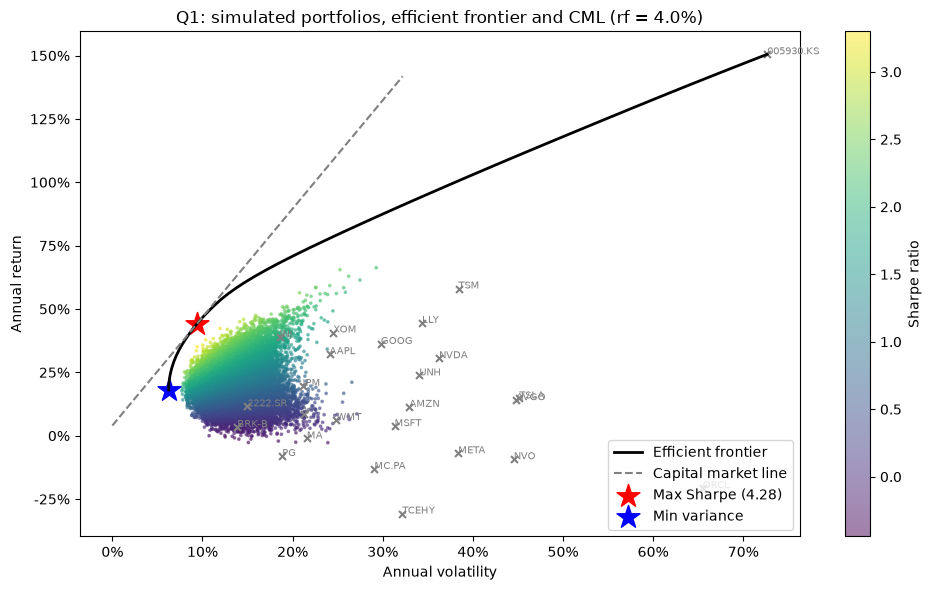

In [7]:
targets = np.linspace(perf(w_minvar)[0], mu.max(), 60)
frontier = []
for t in targets:
    c = cons + ({"type": "eq", "fun": lambda w, t=t: w @ mu.values - t},)
    r = minimize(lambda w: perf(w)[1], w0, method="SLSQP", bounds=bounds, constraints=c)
    frontier.append(r.fun if r.success else np.nan)

r_s, s_s, sh_s = perf(w_sharpe)
r_m, s_m, _ = perf(w_minvar)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(sim_vol, sim_ret, c=sim_sharpe, cmap="viridis", s=3, alpha=0.5)
plt.colorbar(sc, label="Sharpe ratio")
ax.plot(frontier, targets, color="black", lw=2, label="Efficient frontier")
x = np.linspace(0, max(sim_vol.max(), s_s) * 1.1, 50)
ax.plot(x, RF + sh_s * x, "--", color="gray", label="Capital market line")
ax.scatter(vol, mu, marker="x", color="gray", s=25)
for t, v, m in zip(tickers, vol, mu):
    ax.annotate(t, (v, m), fontsize=7, color="gray")
ax.scatter(s_s, r_s, marker="*", color="red", s=300, label=f"Max Sharpe ({sh_s:.2f})")
ax.scatter(s_m, r_m, marker="*", color="blue", s=300, label="Min variance")
ax.set_xlabel("Annual volatility")
ax.set_ylabel("Annual return")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(f"{QUARTER}: simulated portfolios, efficient frontier and CML (rf = {RF:.1%})")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(OUT / "frontier.png", dpi=150)
plt.show()

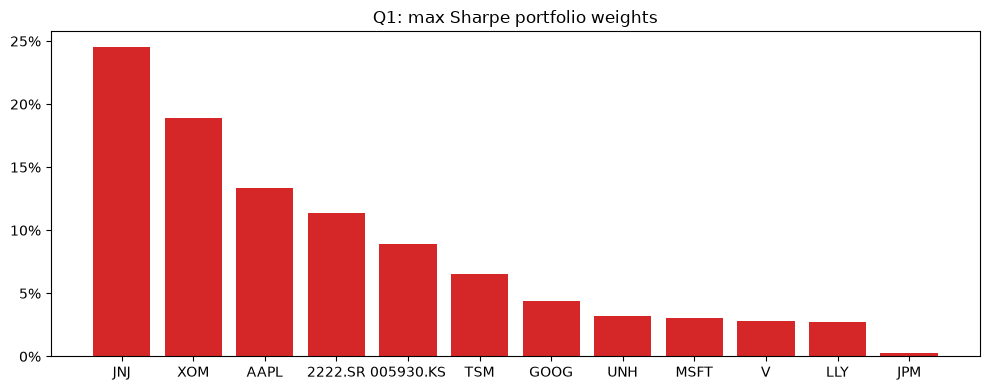

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ws = weights["Max Sharpe"][weights["Max Sharpe"] > 1e-4]
ax.bar(ws.index, ws.values, color="tab:red")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(f"{QUARTER}: max Sharpe portfolio weights")
plt.tight_layout()
fig.savefig(OUT / "weights_max_sharpe.png", dpi=150)
plt.show()

## 5. Leverage (hedge fund)

Two ways to use leverage, both capped at a gross exposure of `LEVERAGE` times capital:

- **A. Borrow at the risk-free rate and lever the max Sharpe portfolio.** Return and volatility scale up together along the CML, so the **Sharpe ratio does not change**.
- **B. Long/short.** Net exposure 100%, gross exposure up to `LEVERAGE`. This widens the opportunity set, so the **Sharpe ratio can rise**.

Financing for B, per year:

- Longs above 100% of capital are bought on margin at `MARGIN_RATE`.
- Short sale proceeds stay with the broker as collateral and earn `SHORT_REBATE`.
- Each short pays `BORROW_FEE` on its value to the stock lender.

So B's return = expected stock returns + short × `SHORT_REBATE` − (long − 100%) × `MARGIN_RATE` − short × `BORROW_FEE`.
The optimizer includes these costs, so a higher fee leads to fewer shorts.

Not modeled: margin calls, hard-to-borrow stocks with higher fees, a spread on margin above the risk-free rate.


In [9]:
# A. Levered tangency portfolio: L in max Sharpe, (1 - L) in cash (negative = borrowing)
lev_ret = MARGIN_RATE + LEVERAGE * (r_s - MARGIN_RATE)
lev_vol = LEVERAGE * s_s
w_lev = LEVERAGE * w_sharpe


# B. Long/short max Sharpe: w = long - short, sum(w) = 1, sum(long + short) <= LEVERAGE
def split(x):
    return x[:n] - x[n:]


def carry(x, rebate, margin, fee):
    long_, short = x[:n].sum(), x[n:].sum()
    return short * rebate - max(long_ - 1, 0) * margin - short * fee


def perf_ls(x, rebate=SHORT_REBATE, margin=MARGIN_RATE, fee=BORROW_FEE):
    r, s, _ = perf(split(x))
    r += carry(x, rebate, margin, fee)
    return r, s, (r - RF) / s


def opt_long_short(**kw):
    cons = (
        {"type": "eq", "fun": lambda x: split(x).sum() - 1},
        {"type": "ineq", "fun": lambda x: LEVERAGE - x.sum()},
    )
    x0 = np.concatenate([w0, np.zeros(n)])
    res = minimize(
        lambda x: -perf_ls(x, **kw)[2],
        x0,
        method="SLSQP",
        bounds=[(0, LEVERAGE)] * (2 * n),
        constraints=cons,
        options={"maxiter": 1000},
    )
    assert res.success, res.message
    x = res.x.copy()
    x[x < 1e-6] = 0
    return x


x_ls0 = opt_long_short(
    rebate=0, margin=0, fee=0
)  # previous version: no financing at all
x_ls = opt_long_short()  # with rebate, margin and borrow fee
w_ls0, w_ls = split(x_ls0), split(x_ls)


def row(r, s, w, borrow=0.0):
    return {
        "Return": r,
        "Volatility": s,
        "Sharpe": (r - RF) / s,
        "Long": w[w > 0].sum(),
        "Short": -w[w < 0].sum(),
        "Gross": np.abs(w).sum(),
        "Borrowed": borrow,
    }


lev_summary = pd.DataFrame(
    {
        "Max Sharpe (no leverage)": row(r_s, s_s, w_sharpe),
        f"A. Levered max Sharpe ({LEVERAGE:.0f}x)": row(
            lev_ret, lev_vol, w_lev, borrow=LEVERAGE - 1
        ),
        "B. Long/short, no financing": row(
            *perf_ls(x_ls0, 0, 0, 0)[:2],
            w_ls0,
            borrow=max(w_ls0[w_ls0 > 0].sum() - 1, 0),
        ),
        f"B. Long/short, rebate + {BORROW_FEE:.1%} fee": row(
            *perf_ls(x_ls)[:2], w_ls, borrow=max(w_ls[w_ls > 0].sum() - 1, 0)
        ),
    }
).T
lev_summary.style.format(
    "{:.2%}", subset=["Return", "Volatility", "Long", "Short", "Gross", "Borrowed"]
).format("{:.2f}", subset=["Sharpe"])

,Return,Volatility,Sharpe,Long,Short,Gross,Borrowed
Max Sharpe (no leverage),44.02%,9.35%,4.28,100.00%,-0.00%,100.00%,0.00%
A. Levered max Sharpe (2x),84.03%,18.71%,4.28,200.00%,-0.00%,200.00%,100.00%
"B. Long/short, no financing",67.16%,12.43%,5.08,150.00%,50.00%,200.00%,50.00%
"B. Long/short, rebate + 0.5% fee",67.16%,12.48%,5.06,150.00%,50.00%,200.00%,50.00%


In [10]:
lev_weights = pd.DataFrame(
    {
        "Max Sharpe": w_sharpe,
        f"A. Levered {LEVERAGE:.0f}x": w_lev,
        "B. No financing": w_ls0,
        "B. Rebate + fee": w_ls,
    },
    index=tickers,
)
lev_weights = lev_weights[(lev_weights.abs() > 1e-4).any(axis=1)].sort_values(
    "B. Rebate + fee", ascending=False
)
lev_weights.style.format("{:.2%}")

,Max Sharpe,A. Levered 2x,B. No financing,B. Rebate + fee
JNJ,24.55%,49.09%,29.86%,29.96%
XOM,18.86%,37.73%,21.23%,21.29%
AAPL,13.39%,26.77%,20.89%,20.99%
2222.SR,11.35%,22.70%,15.78%,15.66%
GOOG,4.36%,8.72%,12.30%,12.37%
TSM,6.55%,13.10%,12.12%,12.17%
005930.KS,8.91%,17.81%,9.82%,9.88%
MSFT,3.03%,6.07%,8.11%,8.10%
UNH,3.17%,6.34%,5.11%,5.12%
V,2.82%,5.64%,5.19%,4.95%


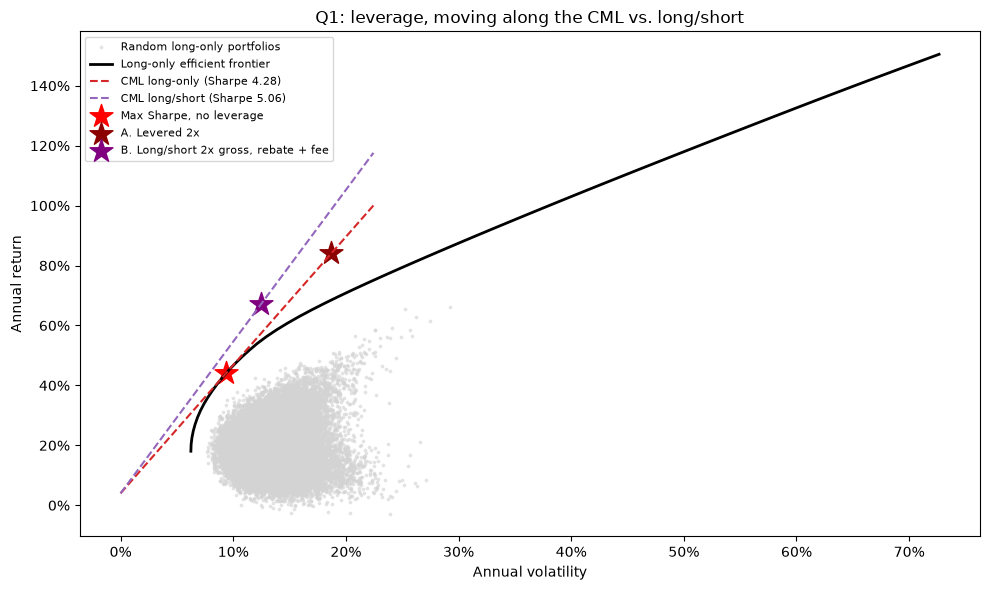

In [11]:
r_ls, s_ls, sh_ls = perf_ls(x_ls)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    sim_vol, sim_ret, c="lightgray", s=3, alpha=0.5, label="Random long-only portfolios"
)
ax.plot(frontier, targets, color="black", lw=2, label="Long-only efficient frontier")
x = np.linspace(0, max(lev_vol, s_ls) * 1.2, 50)
ax.plot(
    x, RF + sh_s * x, "--", color="tab:red", label=f"CML long-only (Sharpe {sh_s:.2f})"
)
ax.plot(
    x,
    RF + sh_ls * x,
    "--",
    color="tab:purple",
    label=f"CML long/short (Sharpe {sh_ls:.2f})",
)
ax.scatter(s_s, r_s, marker="*", color="red", s=300, label="Max Sharpe, no leverage")
ax.scatter(
    lev_vol,
    lev_ret,
    marker="*",
    color="darkred",
    s=300,
    label=f"A. Levered {LEVERAGE:.0f}x",
)
ax.scatter(
    s_ls,
    r_ls,
    marker="*",
    color="purple",
    s=300,
    label=f"B. Long/short {LEVERAGE:.0f}x gross, rebate + fee",
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Annual volatility")
ax.set_ylabel("Annual return")
ax.set_title(f"{QUARTER}: leverage, moving along the CML vs. long/short")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
fig.savefig(OUT / "leverage.png", dpi=150)
plt.show()

## 6. Changes vs. previous quarter

Trades needed to move from last quarter's weights to this quarter's. Skipped if the previous quarter has not been run.

In [12]:
prev_q = f"Q{int(QUARTER[1:]) - 1}" if QUARTER[1:].isdigit() and int(QUARTER[1:]) > 1 else None
prev_file = Path("outputs") / str(prev_q) / f"resultados_sharpe_{prev_q}.xlsx"
if prev_q and prev_file.exists():
    prev_w = pd.read_excel(prev_file, sheet_name="Leverage weights", index_col=0)
    cur_w = pd.DataFrame({"Max Sharpe": w_sharpe, "A. Levered": w_lev, "B. Rebate + fee": w_ls}, index=tickers)
    cols = ["Max Sharpe", "A. Levered", "B. Rebate + fee"]
    change = cur_w[cols].sub(prev_w.reindex(columns=cols), fill_value=0).fillna(0)
    change = change[(change.abs() > 1e-4).any(axis=1)].sort_values("B. Rebate + fee")
    print(f"Weight change {prev_q} -> {QUARTER} (positive = buy, negative = sell)")
    display(change.style.format("{:+.2%}"))
else:
    change = None
    print(f"No previous quarter results found ({prev_file}), skipping comparison")

No previous quarter results found (outputs/None/resultados_sharpe_None.xlsx), skipping comparison


## 7. Trade plan (shares)

Target positions for `STRATEGY` on the current equity, priced at the last price in the file, rounded down to whole shares.

Equity: the `NAV` env var if given (use FinSimCo's actual figure). Otherwise, for Q1 `INITIAL_CAPITAL`; for later quarters, last quarter's shares at today's prices, minus the margin loan and its interest.

In [13]:
last_px = prices.iloc[-1]
end_date = prices.index.max()
target_w = pd.Series(w_lev if STRATEGY == "A" else w_ls, index=tickers)

prev_pos, prev_loan, prev_end = pd.Series(dtype=float), 0.0, None
if prev_q and prev_file.exists():
    prev_xl = pd.read_excel(prev_file, sheet_name=None, index_col=0)
    if "Positions" in prev_xl:
        prev_pos = prev_xl["Positions"]["Shares"]
        prev_loan = float(prev_xl["Parameters"].loc["Margin loan", "Value"])
        prev_end = pd.Timestamp(prev_xl["Parameters"].loc["End", "Value"])

# prices for every ticker held or targeted (a dropped ticker falls back to its last raw price)
px = raw.set_index(date_col).sort_index().apply(pd.to_numeric, errors="coerce").ffill().iloc[-1]
px = px.reindex(prev_pos.index.union(target_w.index))

if NAV is not None:
    capital, capital_src = NAV, "NAV from FinSimCo"
elif len(prev_pos):
    days = (end_date - prev_end).days
    interest = prev_loan * MARGIN_RATE * days / 365
    capital = float((prev_pos * px[prev_pos.index]).sum()) - prev_loan - interest
    capital_src = f"Estimate: {prev_q} shares at today's prices - loan - {days} days interest (${interest:,.0f})"
else:
    capital, capital_src = INITIAL_CAPITAL, "Initial capital"

target_amt = target_w * capital
target_amt[target_amt.abs() < MIN_POSITION] = 0
shares = np.sign(target_amt) * np.floor(target_amt.abs() / px[target_amt.index])

pos = pd.DataFrame({"Price": px}).join(shares.rename("Shares")).join(prev_pos.rename("Prev shares")).fillna(0)
pos["Weight (% equity)"] = pos["Shares"] * pos["Price"] / capital
pos["Amount"] = pos["Shares"] * pos["Price"]
pos["Trade shares"] = pos["Shares"] - pos["Prev shares"]
pos["Trade amount"] = pos["Trade shares"] * pos["Price"]

def action(r):
    if r["Trade shares"] == 0:
        return "Hold" if r["Shares"] else "-"
    if r["Trade shares"] > 0:
        return "Cover" if r["Prev shares"] < 0 else "Buy"
    return "Short" if r["Shares"] < 0 and r["Prev shares"] <= 0 else "Sell"

pos["Action"] = pos.apply(action, axis=1)
pos = pos[(pos["Shares"] != 0) | (pos["Prev shares"] != 0)]
pos = pos[["Action", "Weight (% equity)", "Price", "Prev shares", "Shares", "Trade shares", "Amount", "Trade amount"]]
pos = pos.sort_values("Amount", ascending=False)

long_amt, short_amt = pos.loc[pos.Amount > 0, "Amount"].sum(), -pos.loc[pos.Amount < 0, "Amount"].sum()
margin_loan = max(long_amt - capital, 0)
print(f"Strategy {STRATEGY} | equity ${capital:,.0f} ({capital_src})")
print(f"Long ${long_amt:,.0f} | short ${short_amt:,.0f} | margin loan ${margin_loan:,.0f} | cash left ${capital - long_amt + short_amt + margin_loan:,.0f}")
print(f"Buys ${pos.loc[pos['Trade amount'] > 0, 'Trade amount'].sum():,.0f} | sells ${-pos.loc[pos['Trade amount'] < 0, 'Trade amount'].sum():,.0f}")
pos.style.format({"Weight (% equity)": "{:.2%}", "Price": "${:,.2f}", "Prev shares": "{:,.0f}", "Shares": "{:,.0f}",
                  "Trade shares": "{:+,.0f}", "Amount": "${:,.0f}", "Trade amount": "${:+,.0f}"})

Strategy A | equity $100,000,000 (Initial capital)
Long $199,996,346 | short $-0 | margin loan $99,996,346 | cash left $0
Buys $199,996,346 | sells $-0


,Action,Weight (% equity),Price,Prev shares,Shares,Trade shares,Amount,Trade amount
JNJ,Buy,49.09%,$266.35,0,"184,319","+184,319","$49,093,366","$+49,093,366"
XOM,Buy,37.73%,$165.23,0,"228,337","+228,337","$37,728,123","$+37,728,123"
AAPL,Buy,26.77%,$326.57,0,"81,974","+81,974","$26,770,249","$+26,770,249"
2222.SR,Buy,22.70%,$7.03,0,"3,228,418","+3,228,418","$22,698,361","$+22,698,361"
005930.KS,Buy,17.81%,$215.60,0,"82,627","+82,627","$17,814,381","$+17,814,381"
TSM,Buy,13.10%,$428.03,0,"30,599","+30,599","$13,097,290","$+13,097,290"
GOOG,Buy,8.72%,$330.39,0,"26,387","+26,387","$8,718,001","$+8,718,001"
UNH,Buy,6.34%,$388.28,0,"16,321","+16,321","$6,337,118","$+6,337,118"
MSFT,Buy,6.07%,$492.44,0,"12,321","+12,321","$6,067,353","$+6,067,353"
V,Buy,5.64%,$367.21,0,"15,347","+15,347","$5,635,572","$+5,635,572"


## 8. Export

In [14]:
xlsx = OUT / f"resultados_sharpe_{QUARTER}.xlsx"
params = pd.Series({"Quarter": QUARTER, "Data file": str(DATA_FILE), "Start": prices.index.min().date(),
                    "End": prices.index.max().date(), "Days": len(prices), "Tickers": len(tickers),
                    "Strategy": STRATEGY, "Equity": capital, "Equity source": capital_src, "Long": long_amt, "Short": short_amt, "Margin loan": margin_loan, "Dropped tickers": ", ".join(dropped.index) or "none", "RF": RF, "Leverage": LEVERAGE,
                    "Margin rate": MARGIN_RATE, "Short rebate": SHORT_REBATE, "Borrow fee": BORROW_FEE},
                   name="Value")
with pd.ExcelWriter(xlsx) as xw:
    params.to_excel(xw, sheet_name="Parameters")
    pos.to_excel(xw, sheet_name="Positions")
    summary.to_excel(xw, sheet_name="Summary")
    pd.DataFrame({"Max Sharpe": w_sharpe, "Min variance": w_minvar}, index=tickers).to_excel(xw, sheet_name="Weights")
    lev_summary.to_excel(xw, sheet_name="Leverage summary")
    pd.DataFrame({"Max Sharpe": w_sharpe, "A. Levered": w_lev, "B. No financing": w_ls0, "B. Rebate + fee": w_ls},
                 index=tickers).to_excel(xw, sheet_name="Leverage weights")
    if change is not None:
        change.to_excel(xw, sheet_name="Change vs prev quarter")
    stats.to_excel(xw, sheet_name="Asset stats")
    cov.to_excel(xw, sheet_name="Covariance")
print(f"Saved {xlsx} and charts in {OUT}/")

# Master workbook: one Summary and one Positions sheet per quarter, plus the news log
summary_q = pd.concat([params.astype(str).to_frame(), lev_summary.round(4).astype(str)], keys=["Parameters", "Results"])
sheets = pd.read_excel(MASTER_FILE, sheet_name=None, index_col=None) if MASTER_FILE.exists() else {}
sheets = {k: v for k, v in sheets.items() if not k.startswith(f"{QUARTER} ") and k != "News"}
new = {f"{QUARTER} Summary": summary_q, f"{QUARTER} Positions": pos}
if NEWS_FILE.exists():
    new["News"] = pd.read_csv(NEWS_FILE)
order = lambda k: (k == "News", k)
with pd.ExcelWriter(MASTER_FILE) as xw:
    for k in sorted({**sheets, **new}, key=order):
        if k in new:
            new[k].to_excel(xw, sheet_name=k, index=k != "News")
        else:
            sheets[k].to_excel(xw, sheet_name=k, index=False)
print(f"Updated {MASTER_FILE}: {sorted({**sheets, **new}, key=order)}")

Saved outputs/Q1/resultados_sharpe_Q1.xlsx and charts in outputs/Q1/
Updated outputs/simulaciones_finsimco.xlsx: ['Q1 Positions', 'Q1 Summary', 'News']
